# British Grand Prix - 2026 🇬🇧 | The Race

- This notebook is full post-race technical debrief of The Race - 2026.

## Necessary Imports

In [1]:
# FastF1 Deps
import fastf1

# Data Deps
import pandas as pd

# Visualisation Deps
import matplotlib.pyplot as plt
from plotly.offline import init_notebook_mode

# Core Deps
from pathlib import Path
import sys
sys.path.append(str(Path("../../")))

# Source Deps
from mark_1 import DataLoader, DataPipeline, DataVisualisation
from mark_1.config import CarSpecifications, RaceStrategyConfig

# Plotly Notebook Orchestration
init_notebook_mode(connected=True)

## Notebook-Level Setup and Configurations

In [2]:
# Accessing the Current Working Directory for Absolute Root Path
REPO_ROOT_PATH = Path.cwd().parent.parent.parent

# Pathlib Path Objects for the Notebook
F1_PATH = REPO_ROOT_PATH / "F1"
F1_DATA_PATH = F1_PATH / "data"
CACHE_PATH = F1_PATH / "cache"
CACHE_PATH.mkdir(exist_ok=True)

# Adding the source scripts into the Python Execution Path
if F1_PATH not in sys.path:
    sys.path.append(str(F1_PATH))

## Loading the Event

In [3]:
# Defaulting the Requests for Caching to a Predefined path
# fastf1.Cache.clear_cache(cache_dir=str(CACHE_PATH))
fastf1.Cache.enable_cache(cache_dir=str(CACHE_PATH))

# Enabling Offline Mode
fastf1.Cache.offline_mode(enabled=True)

# The GP Event
britain_2026 = fastf1.get_event(
    year=2026,
    gp="britain"
)
print(britain_2026)

events      WARNING 	Correcting user input 'britain' to 'British Grand Prix'


RoundNumber                                                  9
Country                                         United Kingdom
Location                                           Silverstone
OfficialEventName    FORMULA 1 PIRELLI BRITISH GRAND PRIX 2026
EventDate                                  2026-07-05 00:00:00
EventName                                   British Grand Prix
EventFormat                                  sprint_qualifying
Session1                                            Practice 1
Session1Date                         2026-07-03 12:30:00+01:00
Session1DateUtc                            2026-07-03 11:30:00
Session2                                     Sprint Qualifying
Session2Date                         2026-07-03 16:30:00+01:00
Session2DateUtc                            2026-07-03 15:30:00
Session3                                                Sprint
Session3Date                         2026-07-04 12:00:00+01:00
Session3DateUtc                            2026-07-04 1

In [4]:
britain_2026 = DataLoader(race_event=britain_2026)
gp_weekend = britain_2026.load_data()

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '16', '44', '63', '6', '1', '3', '81', '41', '30', '5', '10', '27', '87', '55', '23', '31', '77', '43', '11', '18', '14']
core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Usi

In [5]:
# Decompiling the Data
race = gp_weekend.race_session

In [6]:
# Loading the Performance data from Quali
quali_performance = pd.read_csv(F1_DATA_PATH / "quali_performance_britain.csv")
quali_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,HAD,28.417,35.831,24.377,88.746,300.0,266.0,248.0,305.0,0.272022,0.240791,0.225226,90.096451,663.258796,938.819907,3.170512,18.510753,38.512529,1.146617,8.196147
1,HAM,28.345,35.738,24.308,88.458,294.0,266.0,243.0,303.0,0.269023,0.243012,0.222772,160.029167,627.041512,975.722222,5.645764,17.545512,40.139963,1.139098,8.224956
2,LEC,28.292,35.614,24.380,88.286,295.0,264.0,245.0,300.0,0.273148,0.244444,0.226182,88.607253,604.733333,892.773920,3.131884,16.980214,36.619111,1.136364,8.297872
3,NOR,28.458,35.976,24.443,88.877,297.0,267.0,245.0,304.0,0.269799,0.241514,0.222631,125.301080,629.245525,964.731944,4.403018,17.490703,39.468639,1.138577,8.196147
4,RUS,28.303,35.629,24.524,88.481,296.0,266.0,248.0,299.0,0.274884,0.247016,0.228368,53.164352,555.321759,830.882870,1.878400,15.586229,33.880398,1.124060,8.283186


## Data Engineering

<img src="../../../assets/circuit_maps/silverstone_map.avif">

In [7]:
# Instantiating the Data Pipeline
data_pipe = DataPipeline(circuit="britain")

# Full Laps Frame
assert race, "Race was not loaded"
race_laps_full = race.laps

# Total no of laps in the race
max_laps = race.laps["LapNumber"].max()

# Drop columns
drop_cols = [
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", 
    "DeletedReason", "FastF1Generated", "IsAccurate",
    "LapStartDate", "LapStartTime"
]

# Filtered Laps
filtered_race_laps = race_laps_full.drop(drop_cols, axis=1)

# Calculating the Driver Deltas
filtered_race_laps = data_pipe.get_traffic_delta(laps_frame=filtered_race_laps)

# Rounding down to the top runners
top_5_drivers = race.results.iloc[:5]["Abbreviation"]
filtered_race_laps = filtered_race_laps.pick_drivers(top_5_drivers.to_list())
filtered_race_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta
0,0 days 00:57:20.252000,NOR,1,0 days 00:01:40.454000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:39.496000,...,307.0,False,MEDIUM,1.0,True,McLaren,12,7.0,False,1.154
1,0 days 00:58:55.088000,NOR,1,0 days 00:01:34.836000,2.0,1.0,NaT,NaT,0 days 00:00:30.170000,0 days 00:00:38.718000,...,304.0,True,MEDIUM,2.0,True,McLaren,12,7.0,False,1.071
2,0 days 01:00:30.329000,NOR,1,0 days 00:01:35.241000,3.0,1.0,NaT,NaT,0 days 00:00:30.061000,0 days 00:00:38.936000,...,308.0,False,MEDIUM,3.0,True,McLaren,1,7.0,False,0.458
3,0 days 01:02:05.445000,NOR,1,0 days 00:01:35.116000,4.0,1.0,NaT,NaT,0 days 00:00:29.899000,0 days 00:00:39.002000,...,310.0,False,MEDIUM,4.0,True,McLaren,1,7.0,False,0.728
4,0 days 01:03:40.599000,NOR,1,0 days 00:01:35.154000,5.0,1.0,NaT,NaT,0 days 00:00:29.884000,0 days 00:00:38.996000,...,304.0,False,MEDIUM,5.0,True,McLaren,1,7.0,False,0.880


In [8]:
# Transforming all the timedelta objects
get_seconds = pd.Timedelta.total_seconds

filtered_race_laps["LapTime"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["LapTime"]),
    axis=1
)
filtered_race_laps["Sector1Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector1Time"]),
    axis=1
)
filtered_race_laps["Sector2Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector2Time"]),
    axis=1
)
filtered_race_laps["Sector3Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector3Time"]),
    axis=1
)

# Picking all the green flag laps without boxing
filtered_race_laps_wo = (
    filtered_race_laps
    .pick_wo_box()
    .pick_track_status(status="1")
    .copy()
)
filtered_race_laps_wo.head()

/var/folders/xn/9t8l06_90tl5nmxrp0jcvlj80000gn/T/ipykernel_61914/219979345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_race_laps["LapTime"] = filtered_race_laps.apply(
/var/folders/xn/9t8l06_90tl5nmxrp0jcvlj80000gn/T/ipykernel_61914/219979345.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_race_laps["Sector1Time"] = filtered_race_laps.apply(
/var/folders/xn/9t8l06_90tl5nmxrp0jcvlj80000gn/T/ipykernel_61914/219979345.py:12: SettingWithCopyWarning: 
A value is trying to be set on 

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta
2,0 days 01:00:30.329000,NOR,1,95.241,3.0,1.0,NaT,NaT,30.061,38.936,...,308.0,False,MEDIUM,3.0,True,McLaren,1,7.0,False,0.458
3,0 days 01:02:05.445000,NOR,1,95.116,4.0,1.0,NaT,NaT,29.899,39.002,...,310.0,False,MEDIUM,4.0,True,McLaren,1,7.0,False,0.728
4,0 days 01:03:40.599000,NOR,1,95.154,5.0,1.0,NaT,NaT,29.884,38.996,...,304.0,False,MEDIUM,5.0,True,McLaren,1,7.0,False,0.880
5,0 days 01:05:15.474000,NOR,1,94.875,6.0,1.0,NaT,NaT,29.883,38.807,...,303.0,False,MEDIUM,6.0,True,McLaren,1,7.0,False,1.224
6,0 days 01:06:50.560000,NOR,1,95.086,7.0,1.0,NaT,NaT,30.129,38.659,...,299.0,False,MEDIUM,7.0,True,McLaren,1,7.0,False,1.428


### Engineering the Aero Features
A comparison of the average speed (weighted by sector time) carried by each of the drivers and teams through the lap. The Silverstone Circuit (one of my favourite tracks ✨), has always been a High-Speed, High-Energy track layout that can be broken as follows:
1. `Front-Axle | High Speed & Medium Downforce` **Sector - 1**: Generically, due to the high-speed nature of the circuit the main tradeoff in setup is always the decision of Downforce (high-speed corners) and Drag (medium-long straights). However, the first sector, is argually one of the highest energy sections on the circuit through turns 1-3 (Abbey, Farm and Village) followed by the Wellington Straight. Thus, to gain time, a car needs to have sufficienty front-end at high-speed.
2. `Balanced | Downforce - Drag Tradeoff` **Sector - 2**: Requires sufficient traction for turns 6-7 😂 (Brooklands and Luffield) followed by another high-speed section through turns 9-14 (Copse, Maggotts, Becketts and Chapel). However, with the current generation of cars, this section is nowhere near as fast as it used to be. Hence a balanced setup is necessary to provide traction while harvesting and carrying the maximum speed possible through the corners.l
3. `Rear-Axle | Drag & Traction` **Sector - 3**: At this, the tyres loose most of their grip and have two long straights before the end of the lap with Stowe (the only real high-energy corner). Thus, a setup with the best traction delivery will perform grip is essential to gain straight line speed while deployment is a bonus.

In [9]:
# Sector - 1: Front Axle Load
filtered_race_laps_wo.loc[:, "FrontAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2: Balanced Load
filtered_race_laps_wo.loc[:, "BalancedAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3: Rear Axle Load
filtered_race_laps_wo.loc[:, "RearAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta,FrontAEI,BalancedAEI,RearAEI
2,0 days 01:00:30.329000,NOR,1,95.241,3.0,1.0,NaT,NaT,30.061,38.936,...,3.0,True,McLaren,1,7.0,False,0.458,0.259847,0.220179,0.211006
3,0 days 01:02:05.445000,NOR,1,95.116,4.0,1.0,NaT,NaT,29.899,39.002,...,4.0,True,McLaren,1,7.0,False,0.728,0.269987,0.219245,0.212467
4,0 days 01:03:40.599000,NOR,1,95.154,5.0,1.0,NaT,NaT,29.884,38.996,...,5.0,True,McLaren,1,7.0,False,0.880,0.270140,0.224480,0.215295
5,0 days 01:05:15.474000,NOR,1,94.875,6.0,1.0,NaT,NaT,29.883,38.807,...,6.0,True,McLaren,1,7.0,False,1.224,0.271929,0.225437,0.217625
6,0 days 01:06:50.560000,NOR,1,95.086,7.0,1.0,NaT,NaT,30.129,38.659,...,7.0,True,McLaren,1,7.0,False,1.428,0.267958,0.228432,0.219588


### Engineering the Kinetic Energy Features

In [10]:
# Sector - 1
filtered_race_laps_wo.loc[:, "KineticEnergyS1_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2
filtered_race_laps_wo.loc[:, "KineticEnergyS2_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3
filtered_race_laps_wo.loc[:, "KineticEnergyS3_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrackStatus,Position,Deleted,TrafficDelta,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ
2,0 days 01:00:30.329000,NOR,1,95.241,3.0,1.0,NaT,NaT,30.061,38.936,...,1,7.0,False,0.458,0.259847,0.220179,0.211006,162.709722,888.723302,1066.712191
3,0 days 01:02:05.445000,NOR,1,95.116,4.0,1.0,NaT,NaT,29.899,39.002,...,1,7.0,False,0.728,0.269987,0.219245,0.212467,-18.495833,910.316667,1059.832099
4,0 days 01:03:40.599000,NOR,1,95.154,5.0,1.0,NaT,NaT,29.884,38.996,...,1,7.0,False,0.880,0.270140,0.224480,0.215295,-18.138426,785.313426,964.731944
5,0 days 01:05:15.474000,NOR,1,94.875,6.0,1.0,NaT,NaT,29.883,38.807,...,1,7.0,False,1.224,0.271929,0.225437,0.217625,-54.415278,782.513735,932.029167
6,0 days 01:06:50.560000,NOR,1,95.086,7.0,1.0,NaT,NaT,30.129,38.659,...,1,7.0,False,1.428,0.267958,0.228432,0.219588,-17.840586,726.013580,860.309414


### Engineering the Power Features

In [11]:
# Sector - 1
filtered_race_laps_wo.loc[:, "PowerS1_KW"] = data_pipe.get_power_expenditure(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2
filtered_race_laps_wo.loc[:, "PowerS2_KW"] = data_pipe.get_power_expenditure(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3
filtered_race_laps_wo.loc[:, "PowerS3_KW"] = data_pipe.get_power_expenditure(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrafficDelta,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW
2,0 days 01:00:30.329000,NOR,1,95.241,3.0,1.0,NaT,NaT,30.061,38.936,...,0.458,0.259847,0.220179,0.211006,162.709722,888.723302,1066.712191,5.412652,22.825234,40.645945
3,0 days 01:02:05.445000,NOR,1,95.116,4.0,1.0,NaT,NaT,29.899,39.002,...,0.728,0.269987,0.219245,0.212467,-18.495833,910.316667,1059.832099,-0.618610,23.340256,40.428461
4,0 days 01:03:40.599000,NOR,1,95.154,5.0,1.0,NaT,NaT,29.884,38.996,...,0.880,0.270140,0.224480,0.215295,-18.138426,785.313426,964.731944,-0.606961,20.138307,36.718122
5,0 days 01:05:15.474000,NOR,1,94.875,6.0,1.0,NaT,NaT,29.883,38.807,...,1.224,0.271929,0.225437,0.217625,-54.415278,782.513735,932.029167,-1.820944,20.164242,35.594011
6,0 days 01:06:50.560000,NOR,1,95.086,7.0,1.0,NaT,NaT,30.129,38.659,...,1.428,0.267958,0.228432,0.219588,-17.840586,726.013580,860.309414,-0.592140,18.779937,32.713872


### Engineering the Fuel and Pace Features

In [12]:
# Instances of all the configs
car_spec = CarSpecifications()
race_spec = RaceStrategyConfig()

In [13]:
# Engineering all the pace features using the pipeline
driver_fuel_flow = {}

mean_race_laps = data_pipe.get_mean_race_laps(
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

effective_fuel_load = data_pipe.get_effective_fuel_load(
    max_fuel_load_in_kg=car_spec.MAX_FUEL_LOAD_IN_KG,
    fuel_sample_limit=race_spec.FUEL_SAMPLE_LIMIT,
    fuel_strat=race_spec.FUEL_STRAT
)

for _, row in mean_race_laps.iterrows():
    fuel_flow = data_pipe.get_effective_fuel_flow(
        effective_fuel_load=effective_fuel_load,
        avg_laptime=row["LapTime"],
        race_laps=max_laps
    )
    driver_fuel_flow[row["Driver"]] = fuel_flow

driver_fuel_flow

{'HAD': np.float64(12.615807598353125),
 'HAM': np.float64(12.672223004962879),
 'LEC': np.float64(12.71274835635441),
 'NOR': np.float64(12.640060019897899),
 'RUS': np.float64(12.682552741562105)}

In [14]:
# LapFuelBurn: Fuel burnt over a single lap based on laptime
filtered_race_laps_wo.loc[:, "LapFuelBurn"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_lap_fuel_burn(
        laptime=x["LapTime"],
        effective_fuel_flow=driver_fuel_flow[x["Driver"]]
    ), 
    axis=1
)

# CumulativeFuelBurn: The fuel burnt over the race distance based on laptimes
filtered_race_laps_wo.loc[:, "CumulativeFuelBurn"] = (
    filtered_race_laps_wo
    .groupby("Driver")["LapFuelBurn"]
    .cumsum()
)

# LapFuelPenality: Zero-Fuel Pace for each race lap based on the cumulative fuel burn offset
filtered_race_laps_wo.loc[:, "LapFuelPenality"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_lap_fuel_penality(
        cumulative_fuel_burn=x["CumulativeFuelBurn"],
        effective_fuel_load=effective_fuel_load
    ),
    axis=1
)

# FuelAwareLapTime: Final Zero-Fuel laptime within the assumed parameters
filtered_race_laps_wo["FuelAwareLapTime"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_fuel_aware_laptime(
        laptime=x["LapTime"], 
        fuel_penality=x["LapFuelPenality"]
    ),
    axis=1
)
filtered_race_laps_wo.tail()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,LapFuelBurn,CumulativeFuelBurn,LapFuelPenality,FuelAwareLapTime
946,0 days 02:02:50.553000,RUS,63,92.686,42.0,3.0,NaT,NaT,29.755,37.460,...,18.138426,741.739506,864.211111,0.609593,19.800841,33.929218,1.175495,39.405414,0.677838,92.008162
947,0 days 02:04:23.308000,RUS,63,92.755,43.0,3.0,NaT,NaT,29.657,37.409,...,0.000000,721.039660,858.016049,0.000000,19.274497,33.400134,1.176370,40.581784,0.642546,92.112454
948,0 days 02:05:55.799000,RUS,63,92.491,44.0,3.0,NaT,NaT,29.681,37.277,...,91.883488,851.820988,1034.098765,3.095701,22.851114,40.500480,1.173022,41.754806,0.607356,91.883644
949,0 days 02:07:28.941000,RUS,63,93.142,45.0,3.0,NaT,NaT,29.670,37.724,...,-74.340741,833.325154,985.818981,-2.505586,22.090053,38.287206,1.181278,42.936085,0.571917,92.570083
950,0 days 02:09:01.927000,RUS,63,92.986,46.0,3.0,NaT,NaT,29.703,37.579,...,53.879167,705.522222,872.937809,1.813930,18.774375,33.961166,1.179300,44.115385,0.536538,92.449462


In [15]:
max_fuel_burns = filtered_race_laps_wo.groupby("Driver")["CumulativeFuelBurn"].last().reset_index()

# Sanity Check for Fuel Load
print(f"Effective Fuel Load: {effective_fuel_load}")

print("\nDriver | Max Fuel Burn")
for _, row in max_fuel_burns.iterrows():
    print(row["Driver"], " | ", row["CumulativeFuelBurn"])

Effective Fuel Load: 62

Driver | Max Fuel Burn
HAD  |  45.30769230769231
HAM  |  46.5
LEC  |  47.692307692307686
NOR  |  46.49999999999999
RUS  |  44.11538461538461


## Data Visualisation

In [16]:
# Instantiating the Data Visualisation Handle
assert race is not None, "The race session wasn't loaded"

data_vis = DataVisualisation(
    session=race,
    driver_names=top_5_drivers.to_list(),
    circuit="britain"
)

req            INFO 	Using cached data for driver_info


### Simple Tyre Degradation Plots

/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly condi

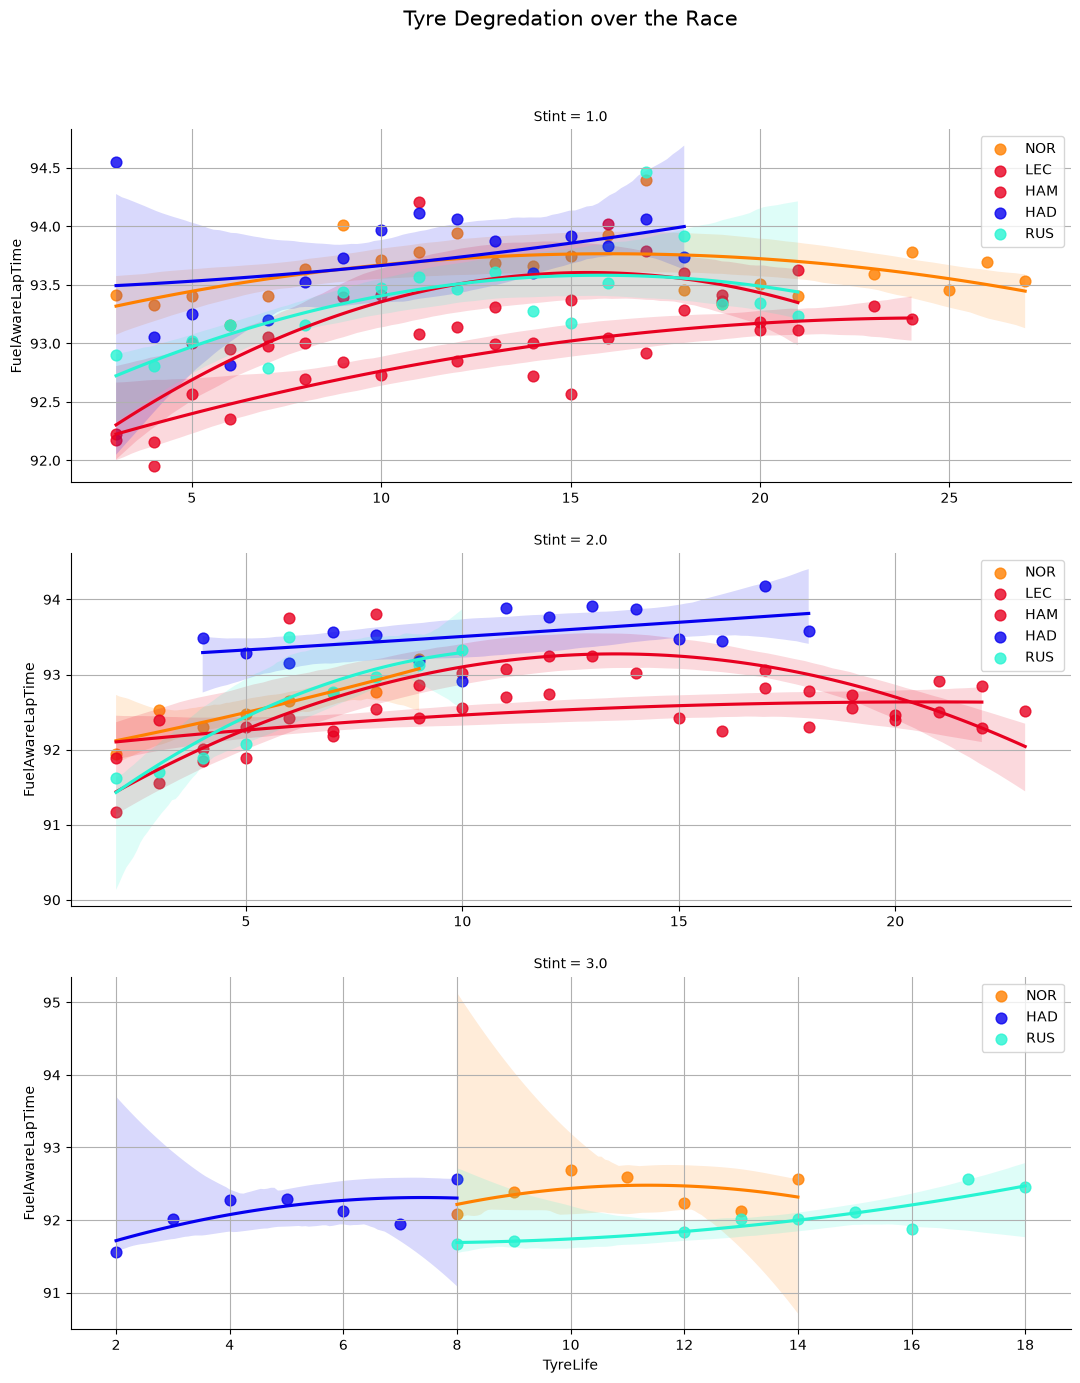

In [17]:
pace_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="FuelAwareLapTime",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

pace_deg_grid.figure.suptitle(
    "Tyre Degredation over the Race",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.2)
plt.show()

**Important**
- In stint-3 Leclerc and Hamilton are missing as they didn't have any green flag laps which hence have already been filtered out during preprocessing.

/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly condi

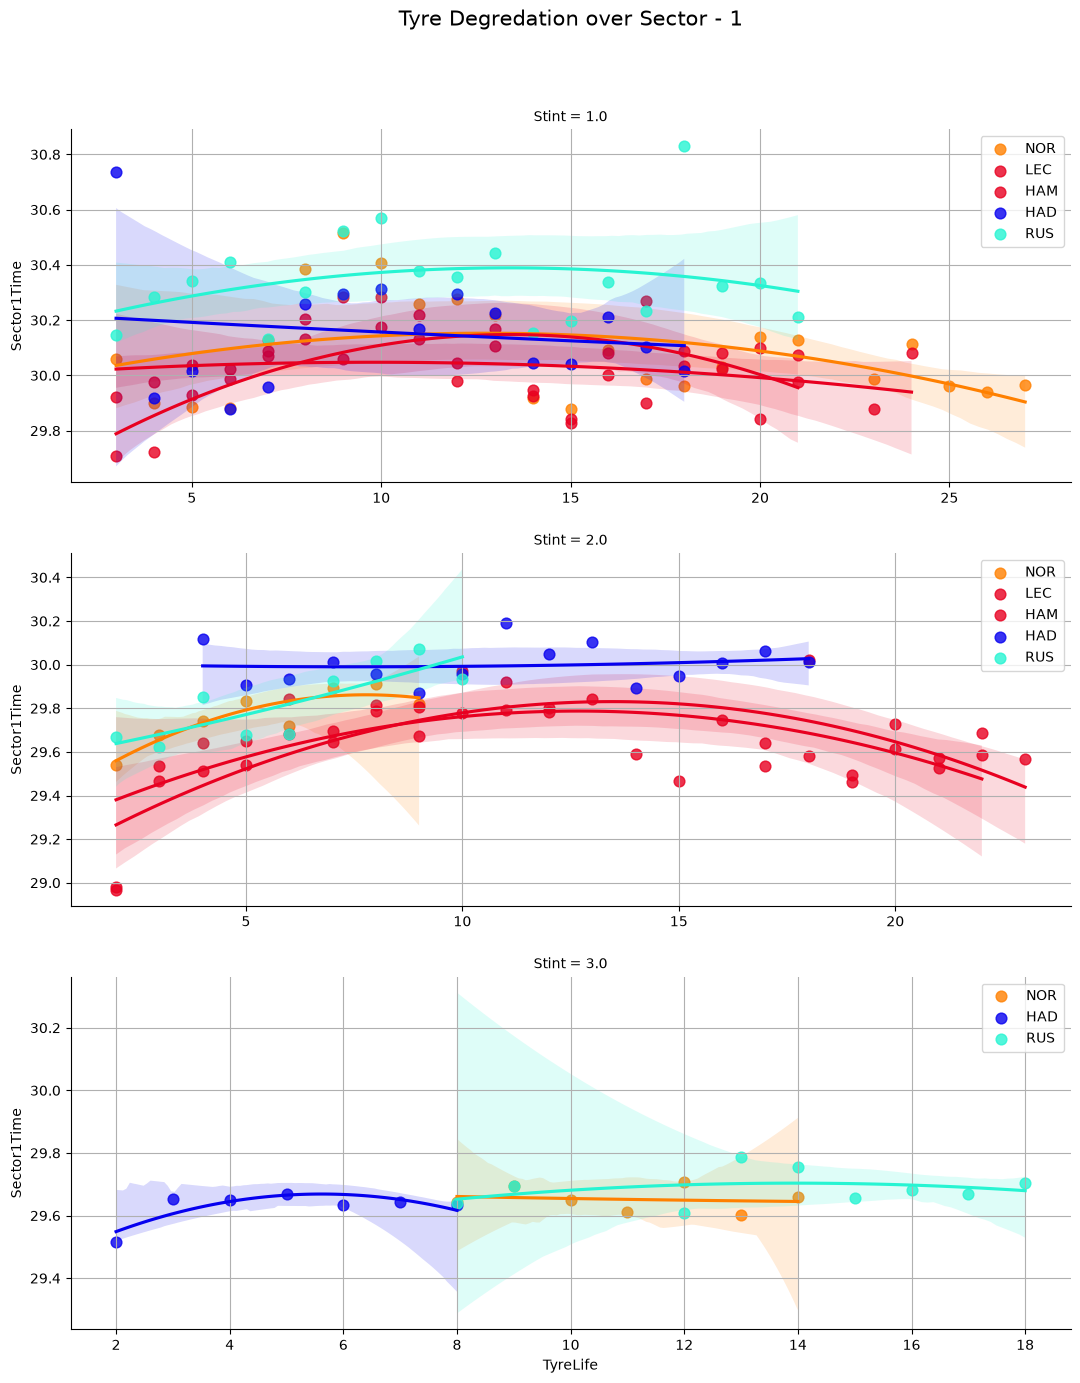

In [18]:
sector1_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector1Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector1_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 1",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.2)
plt.show()

/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly condi

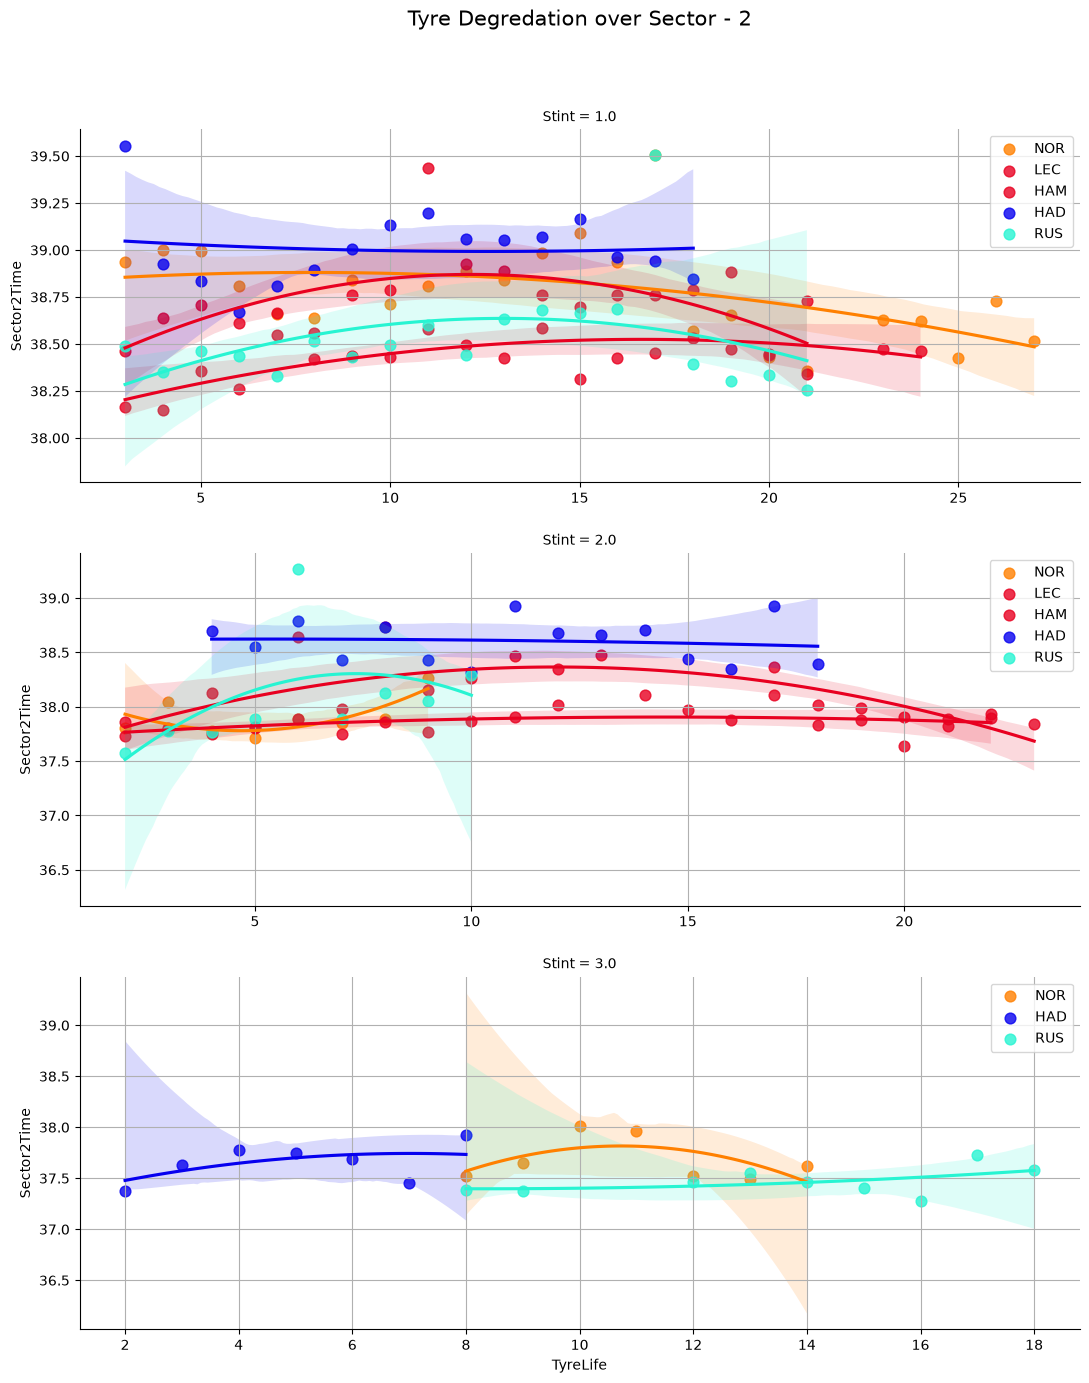

In [19]:
sector2_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector2Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector2_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 2",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.2)
plt.show()

/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/shadowmonarch/Development/Racing-all-Along/.venv/lib/python3.13/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)


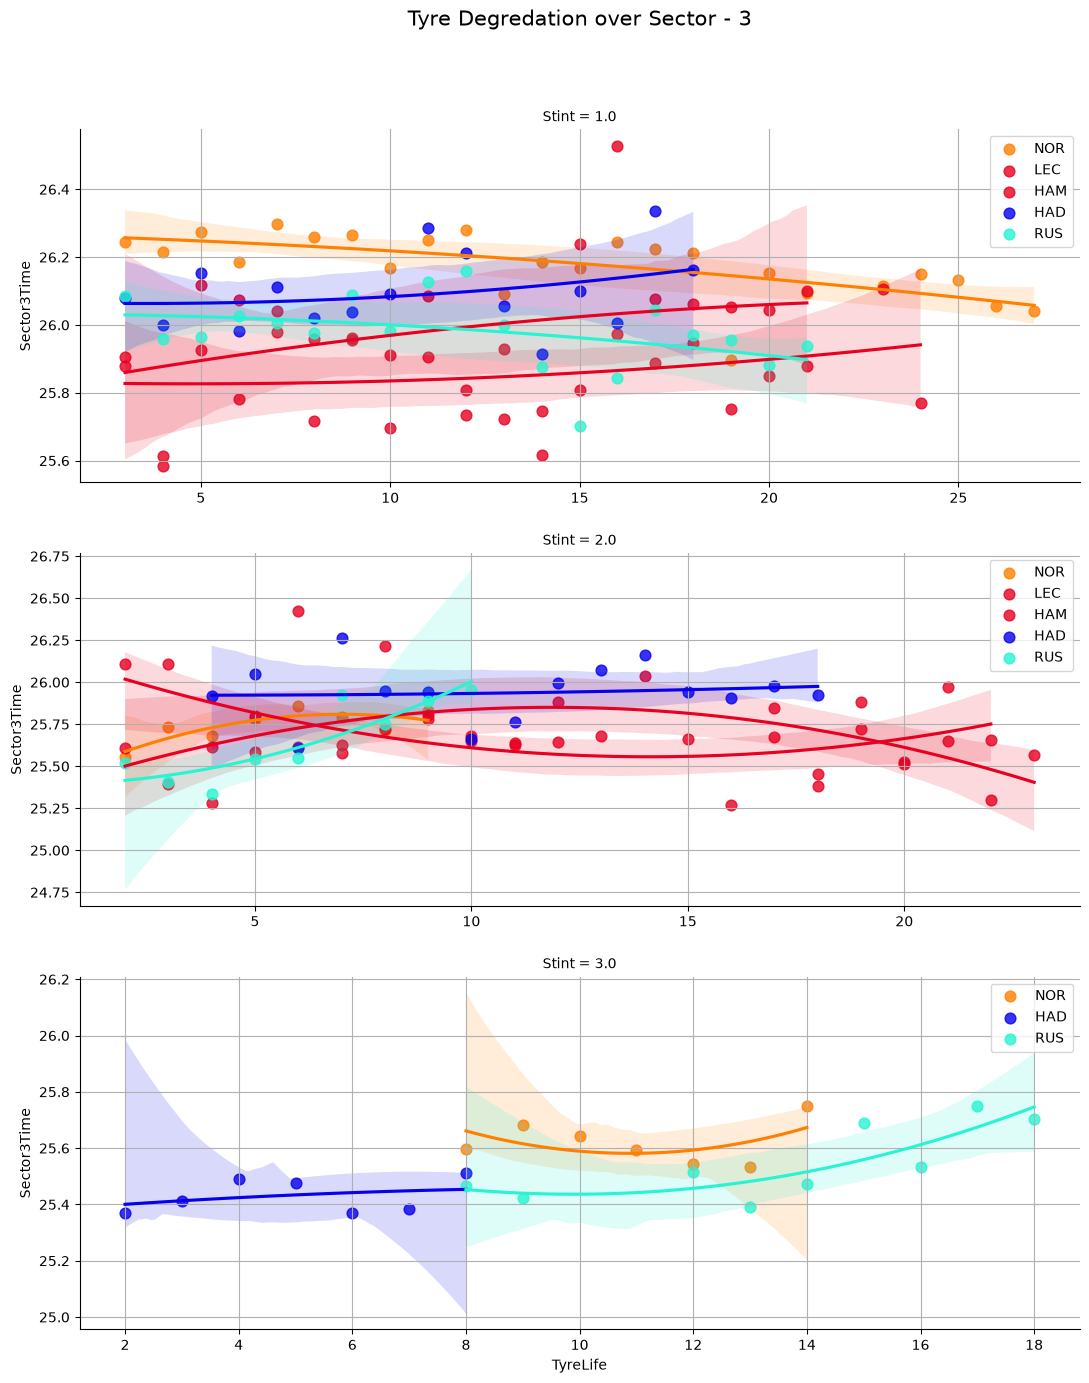

In [20]:
sector3_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector3Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector3_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 3",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.2)
plt.legend(loc="upper right")
plt.show()

### Raw Pace Plots

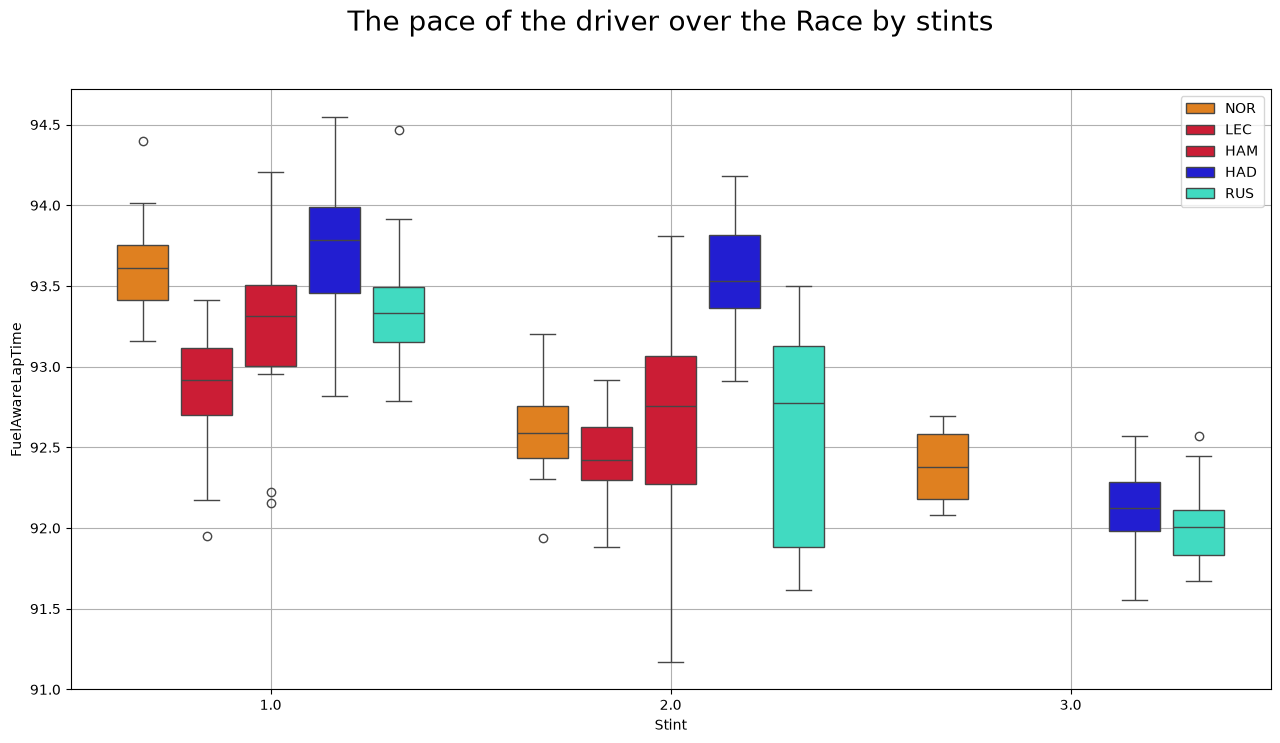

In [21]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="FuelAwareLapTime",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver over the Race by stints",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

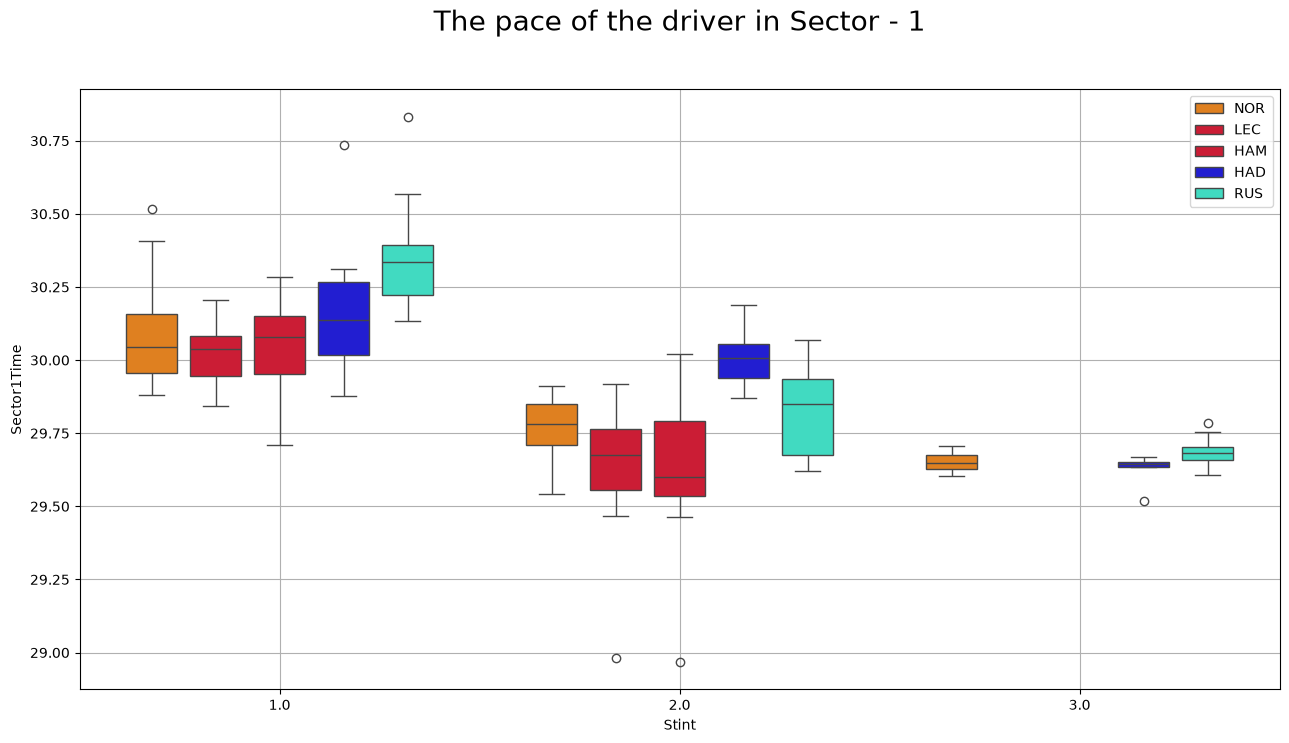

In [22]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector1Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 1",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

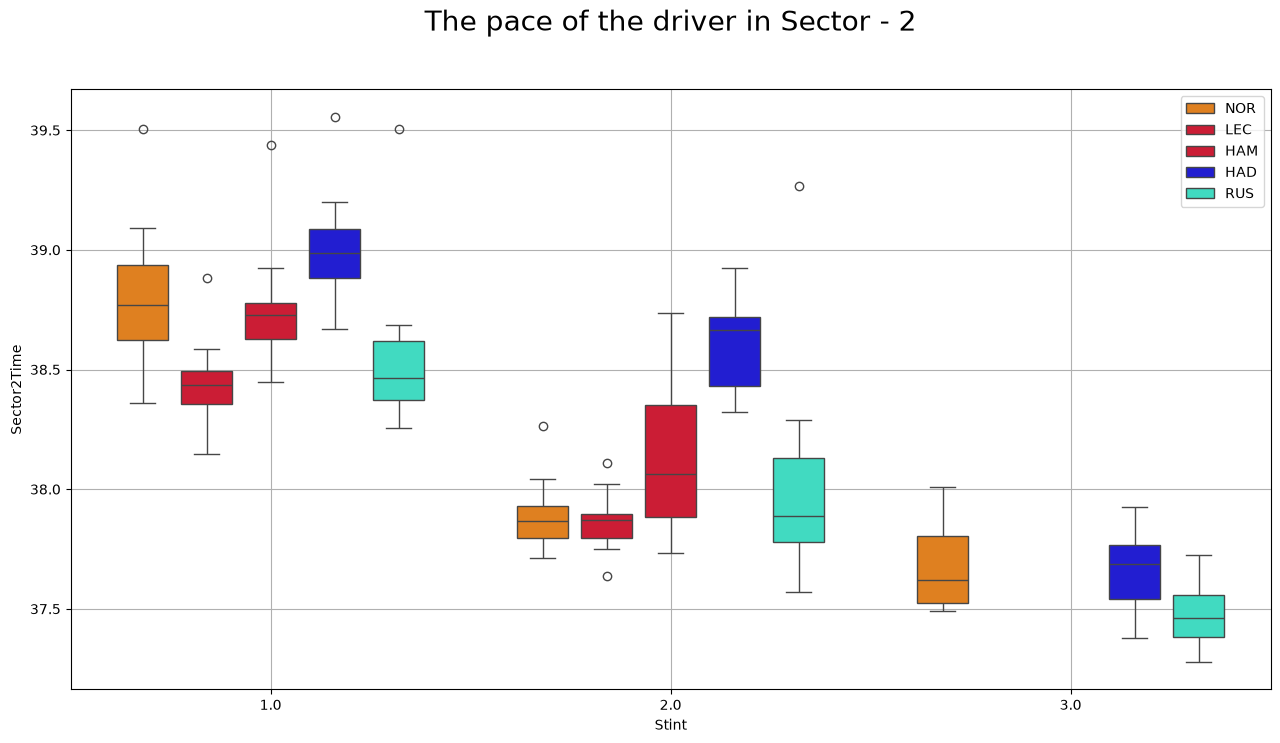

In [23]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector2Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 2",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

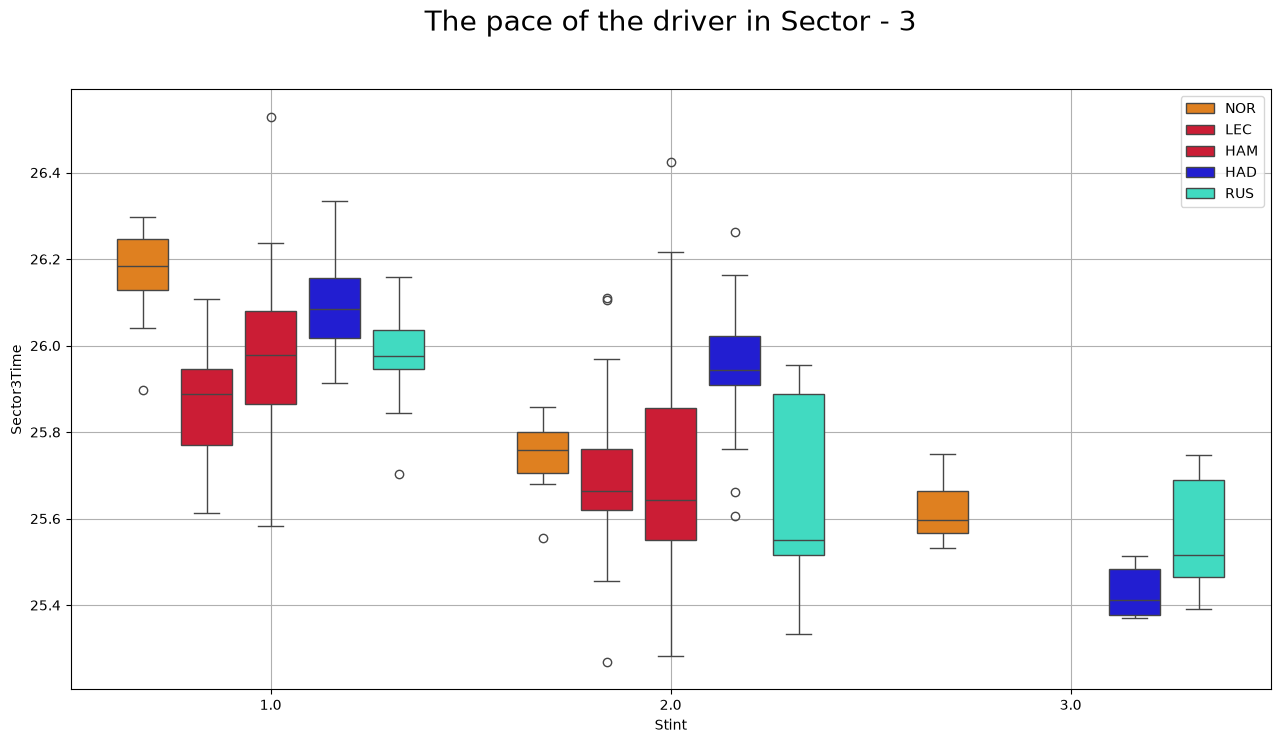

In [24]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector3Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 3",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

### KE Retention Plots

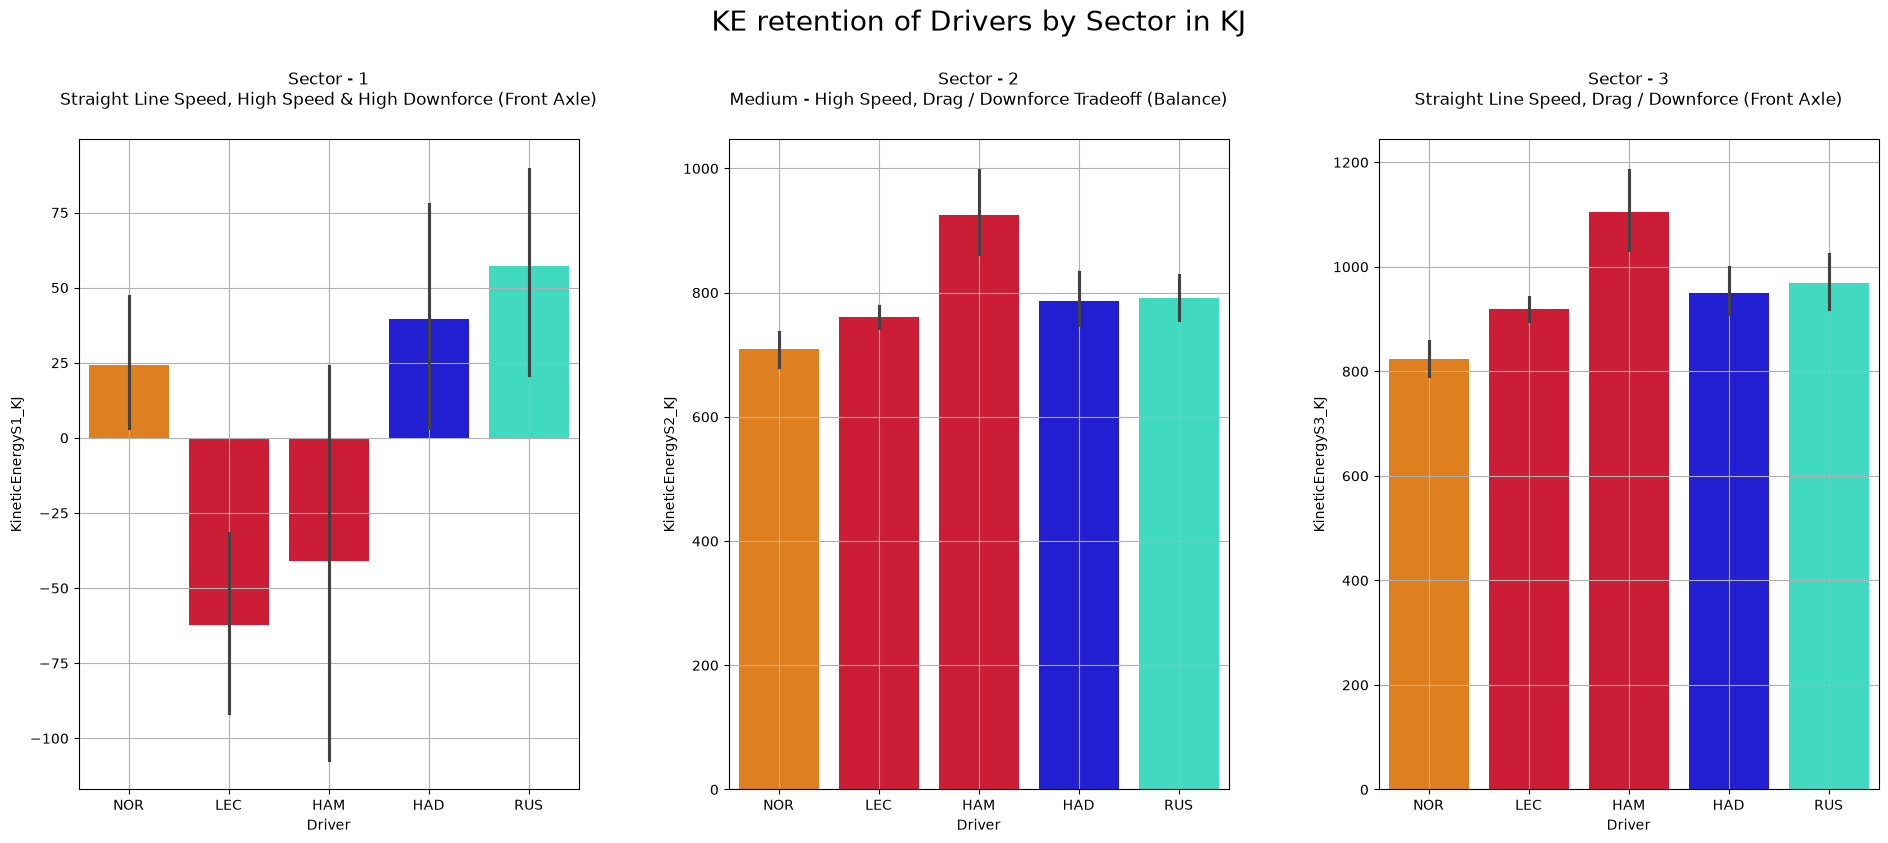

In [25]:
ke_grid = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=filtered_race_laps_wo,
    hue="Driver",
    plot_kind="ke"
)

ke_grid.suptitle(
    t="KE retention of Drivers by Sector in KJ",
    fontsize=20
)
plt.subplots_adjust(
    left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.3
)
plt.show()

### Power Deployment Plots

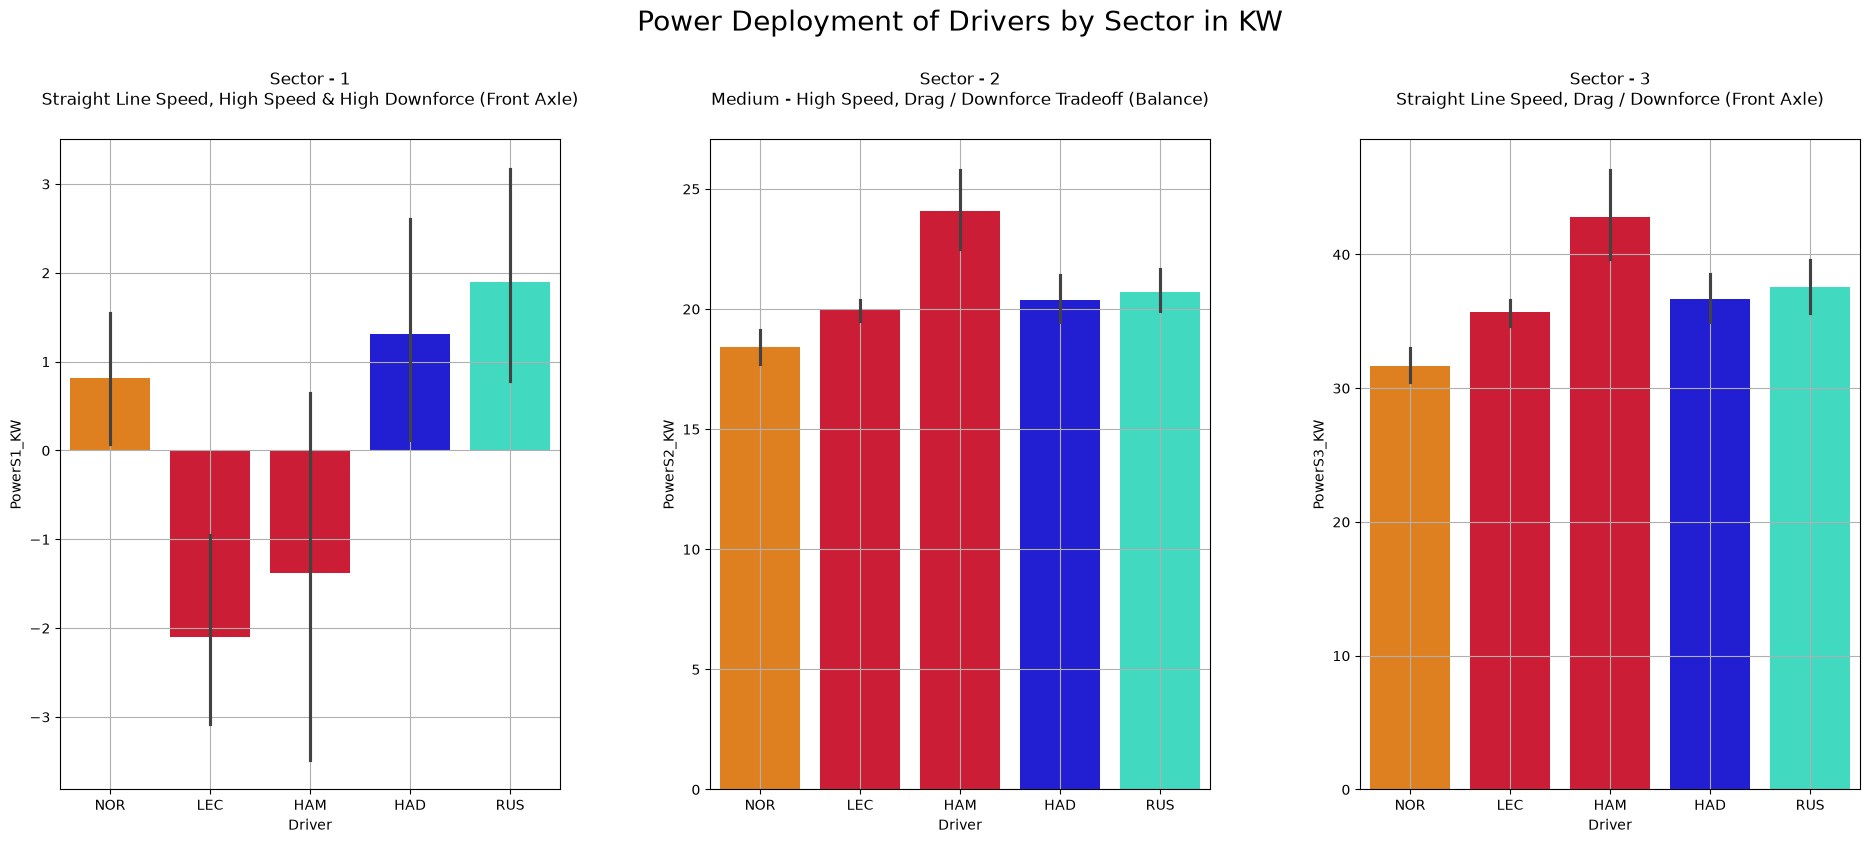

In [26]:
ke_grid = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=filtered_race_laps_wo,
    hue="Driver",
    plot_kind="power"
)

ke_grid.suptitle(
    t="Power Deployment of Drivers by Sector in KW",
    fontsize=20
)
plt.subplots_adjust(
    left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.3
)
plt.show()

### Quali Trim vs Race Trim

In [27]:
# Generating all the features
race_performance = data_pipe.get_mean_race_laps(
    laps_frame=filtered_race_laps,
    drivers=top_5_drivers.to_list()
)

# ================ Aero Features ================
race_performance.loc[:, "FrontAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI1"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector1Time"],
        purple_sector_time=race_performance["Sector1Time"].min()
    ),
    axis=1
)
race_performance.loc[:, "BalancedAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI2"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector2Time"],
        purple_sector_time=race_performance["Sector2Time"].min()
    ),
    axis=1
)
race_performance.loc[:, "RearAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedFL"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector3Time"],
        purple_sector_time=race_performance["Sector3Time"].min()
    ),
    axis=1
)

# ================ Kinetic Energy Features ================
race_performance.loc[:, "KineticEnergyS1_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
race_performance.loc[:, "KineticEnergyS2_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI2"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
race_performance.loc[:, "KineticEnergyS3_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# ================ Power Features ================
race_performance["PowerS1_KW"] = (
    race_performance["KineticEnergyS1_KJ"] / 
    race_performance["Sector1Time"]
)
race_performance["PowerS2_KW"] = (
    race_performance["KineticEnergyS2_KJ"] / 
    race_performance["Sector2Time"]
)
race_performance["PowerS3_KW"] = (
    race_performance["KineticEnergyS3_KJ"] / 
    race_performance["Sector3Time"]
)

# ================ Auxiliary Features ================
# ERS Clipping
race_performance["ERS_Clipping"] = race_performance["SpeedST"] / race_performance["SpeedI1"]

# Acceleration Time
race_performance.loc[:, "AccelerationTime"] = race_performance.apply(
    lambda x: data_pipe.get_delta_acceleration_time(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

race_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,HAD,32.833059,40.455538,27.330404,99.354804,291.903846,246.923077,240.632653,295.461538,0.270009,0.232084,0.226096,62.238488,784.107617,875.452974,1.895604,19.381960,32.032200,1.012188,7.967783
1,HAM,32.574196,40.726077,27.314173,97.943560,296.519231,245.269231,237.320000,298.192308,0.273927,0.226901,0.221073,29.634976,856.635766,970.893349,0.909768,21.034085,35.545405,1.005642,7.869361
2,LEC,32.303824,40.975654,27.322135,96.352163,293.769231,244.615385,238.360000,289.442308,0.281930,0.231718,0.228687,-75.160141,713.032635,803.015811,-2.326664,17.401373,29.390669,0.985271,8.024533
3,NOR,32.641902,40.477077,27.470173,99.300902,286.480769,247.365385,240.673469,286.442308,0.274938,0.239693,0.232068,-0.656304,621.280168,718.552009,-0.020106,15.348939,26.157535,0.999866,8.168636
4,RUS,32.765451,40.445077,27.390327,97.929940,285.288462,246.211538,238.140000,292.807692,0.266831,0.233573,0.225288,129.466020,748.060346,864.499571,3.951297,18.495708,31.562222,1.026357,8.095539


In [28]:
# Rescaling the Features
quali_performance_rescaled = data_pipe.get_rescaled_direct_features(
    laps_frame=quali_performance
)
quali_performance_rescaled = data_pipe.get_rescaled_inverse_features(
    laps_frame=quali_performance_rescaled
)

race_performance_rescaled = data_pipe.get_rescaled_direct_features(
    laps_frame=race_performance
)
race_performance_rescaled = data_pipe.get_rescaled_inverse_features(
    laps_frame=race_performance_rescaled
)

race_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,HAD,0.000010,98.028281,89.595671,0.000010,58.904120,83.916094,98.782873,76.759421,21.047901,40.517730,45.686371,32.853840,30.816421,37.821944,1.895604,19.381960,32.032200,34.485831,67.113225
1,HAM,48.912610,47.038792,100.000010,47.000104,100.000010,23.776234,0.000010,100.000010,46.991050,0.000010,0.000010,48.787049,0.000010,0.000010,0.909768,21.034085,35.545405,50.417217,100.000010
2,LEC,100.000010,0.000010,94.896460,100.000010,75.513709,0.000010,31.012668,25.531925,100.000010,37.650488,69.254160,100.000010,61.015398,66.527967,-2.326664,17.401373,29.390669,100.000010,48.150879
3,NOR,36.119457,93.968839,0.000010,1.795162,10.616448,100.000010,100.000010,0.000010,53.687752,100.000010,100.000010,63.590278,100.000010,100.000010,-0.020106,15.348939,26.157535,64.477248,0.000010
4,RUS,12.774639,100.000010,51.183442,47.453704,0.000010,58.041968,24.452298,54.173496,0.000010,52.158329,38.337261,0.000010,46.132510,42.162653,3.951297,18.495708,31.562222,0.000010,24.424677


In [29]:
polar_fig = data_vis.create_comparison_radar(
    quali_performance=quali_performance_rescaled,
    race_performance=race_performance_rescaled,
    drivers=top_5_drivers.to_list(),
    show_pace_categories=True,
    show_speed_categories=True,
    show_energy_categories=True,
)

polar_fig.show()

## Fin, Cheers!!!